# Phase 6 — 3D 위치·박스 개선 (실무 방식 재구성)

**목표**: 05 노트북의 기준선(raw: 박스 안 점의 깊이 통계) 을 ROI → 지면 제거 → 프러스텀 → DBSCAN → 클러스터 선택 → 표면→중심 오프셋 → AABB/OBB 로 개선한다.
정답지는 `src/perceptrack3d/fusion/point_filters.py` 와 `frustum_fusion.py::fuse_frame_clustered`, 비교 수치는 `outputs/phase6/comparison.md`. 프레임 174 를 예제로 쓴다.

## 이 노트북에서 가져오는 것

| 조각 | 출처 | 라이선스 | 왜 |
|---|---|---|---|
| 1. ROI 필터 | NumPy 문서 "Boolean array indexing" | BSD-3 (문서) | 카메라 뒤·너무 먼 점 제거, RANSAC 입력 절반으로 |
| 2. 지면 제거 (RANSAC 평면) | Open3D 튜토리얼 "Plane segmentation" (`segment_plane`) | MIT | 박스 아래 도로 점이 물체와 한 덩어리로 묶이는 것을 막음 |
| 3. DBSCAN 클러스터링 | Open3D 튜토리얼 "DBSCAN clustering" (`cluster_dbscan`) + scikit-learn `DBSCAN` 문서(교차 검증) | MIT / BSD-3 | 물체 덩어리와 뒤 배경 덩어리를 공간적으로 분리 |
| 4. 클러스터 선택 규칙 (largest vs nearest) | 출처 없음 — 직접 작성 | — | 여러 덩어리 중 무엇이 물체인가 |
| 5. 표면→중심 오프셋 | 출처 없음 — GT 와 비교해 고안, 직접 작성 (크기 prior 는 tracklet GT 에서 계산) | KITTI (GT) | 05 에서 본 표면 편향(−1.3 m) 보정 |
| 6. AABB / OBB | NumPy `min`/`max`, `numpy.linalg.eigh` 문서 (PCA) | BSD-3 (문서) | 3D 박스 크기·방향 |

규칙: 정답지 모듈(`perceptrack3d.fusion.*`) 은 **검증 셀(C)** 에서만 import 한다. 05 노트북에서 직접 작성한 `shrink`/`in_box`/`bev_corners` 는 준비 셀에 다시 적는다 (노트북 간 import 는 하지 않는다).
Open3D 창은 띄우지 않는다 (`draw_geometries` 호출은 주석 처리). 그림은 matplotlib.

In [1]:
%matplotlib inline
import copy
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d

from perceptrack3d.config import load_config
from perceptrack3d.data.kitti_loader import KittiDataset                     # Phase 1
from perceptrack3d.geometry.calibration import KittiCalibration              # Phase 2
from perceptrack3d.detection.detector import load_detections_json            # Phase 4 결과(JSON)
from perceptrack3d.evaluation.tracklets import gt_boxes_by_frame, gt_in_front_fov, load_tracklets   # GT (비교·prior 용)

cfg = load_config()                                   # 경로는 여기서만
ds = KittiDataset(cfg)
calib = KittiCalibration.from_dir(cfg["dataset"]["calib_dir"])
dets_all = load_detections_json(f"{cfg['outputs']['dir']}/phase4/detections.json")
gts_all = gt_boxes_by_frame(ds.tracklets_path)
F = cfg["fusion"]

FRAME = 174
fr = ds.load_frame(FRAME)
img, pts = fr["image"], fr["points"]
H, W = img.shape[:2]
dets = dets_all[FRAME]
gts = [b for b in gt_in_front_fov(gts_all[FRAME]) if b.center[0] <= F["roi"]["x_max"]]

# --- 05 노트북에서 직접 작성한 함수·결과를 그대로 가져온다 (조각 1·2·5) ---
def shrink(xyxy, s):
    x1, y1, x2, y2 = [float(v) for v in xyxy]
    w, h = x2 - x1, y2 - y1
    return np.array([x1 + s * w, y1 + s * h, x2 - s * w, y2 - s * h])

def in_box(pts_2d, xyxy):
    xmin, ymin, xmax, ymax = xyxy
    return (pts_2d[:,0]<xmax) & (pts_2d[:,0]>=xmin) & (pts_2d[:,1]<ymax) & (pts_2d[:,1]>=ymin)

def bev_corners(center, size, yaw):
    l, w = size[0], size[1]
    local = np.array([[l/2, w/2], [l/2, -w/2], [-l/2, -w/2], [-l/2, w/2]])
    c, s = np.cos(yaw), np.sin(yaw)
    return local @ np.array([[c, -s], [s, c]]).T + center[:2]

pc_velo = pts[:, :3].astype(np.float64)                                    # (N, 3) Velodyne
proj = np.hstack((pc_velo, np.ones((len(pc_velo), 1)))) @ calib.P_velo_to_img.T   # (N, 3) = [u·d, v·d, d]
depth_all = proj[:, 2]
with np.errstate(divide="ignore", invalid="ignore"):
    pts_2d = proj[:, :2] / depth_all[:, None]
in_img = in_box(pts_2d, (0, 0, W, H)) & (pc_velo[:, 0] > 2.0)
box_sel = [np.flatnonzero(in_box(pts_2d, shrink(d.xyxy, F["box_shrink"])) & in_img) for d in dets]   # 축소 박스 안 점 (원본 인덱스)

def nearest_gt(c):
    d = np.array([np.linalg.norm(c[:2] - b.center[:2]) for b in gts]); j = int(d.argmin())
    return gts[j], float(d[j])

print("points", pts.shape, "| 이미지 안", in_img.sum(), "| detections", len(dets), "| GT", len(gts))
print("축소 박스 안 점 수:", [len(s) for s in box_sel])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


points (119911, 4) | 이미지 안 18300 | detections 7 | GT 10
축소 박스 안 점 수: [97, 112, 30, 20, 25, 13, 83]


### 조각 1. ROI 필터 — NumPy boolean indexing

- **검색어**: `numpy filter points by coordinate range boolean mask`
- **출처**: NumPy 공식 문서 "Indexing on ndarrays" › Boolean array indexing — https://numpy.org/doc/stable/user/basics.indexing.html#boolean-array-indexing — BSD-3-Clause (문서) — 2026-09-08 — `notebooks_2nd/sources/numpy_docs/indexing_boolean.txt`
- **왜 이걸 가져오나**: 지면 RANSAC 에 12만 점을 다 넣을 이유가 없다. 카메라 뒤(x < 0), 70 m 밖, 높이 ±3 m 밖의 점은 융합에 쓰이지 않으므로 먼저 버린다. 비교 연산으로 bool 배열을 만들고 `&` 로 합치는 것이 전부다.
- **읽을 때 볼 곳**: "A single boolean index array is practically identical to `x[obj.nonzero()]`", 예제 `x[~np.isnan(x)]`, `x[x < 0] += 20`.

In [2]:
# ORIGINAL: numpy docs :: Indexing on ndarrays › Boolean array indexing (Examples), BSD-3-Clause
x = np.array([[1., 2.], [np.nan, 3.], [np.nan, np.nan]])
print(x[~np.isnan(x)])                 # array([1., 2., 3.])
x = np.array([1., -1., -2., 3])
x[x < 0] += 20
print(x)                               # array([ 1., 19., 18., 3.])
x = np.arange(35).reshape(5, 7)
b = x > 20
print(b[:, 5])                         # array([False, False, False,  True,  True])
print(x[b[:, 5]])                      # 행 선택: (2, 7)

[          1           2           3]
[          1          19          18           3]
[False False False  True  True]
[[21 22 23 24 25 26 27]
 [28 29 30 31 32 33 34]]


ROI: {'x_min': 0.0, 'x_max': 70.0, 'y_abs_max': 40.0, 'z_min': -3.0, 'z_max': 3.0}
전체 119911 → ROI 61669 (51%) | ROI 점 x 0.0~70.0, y -40.0~39.9, z -2.97~2.61


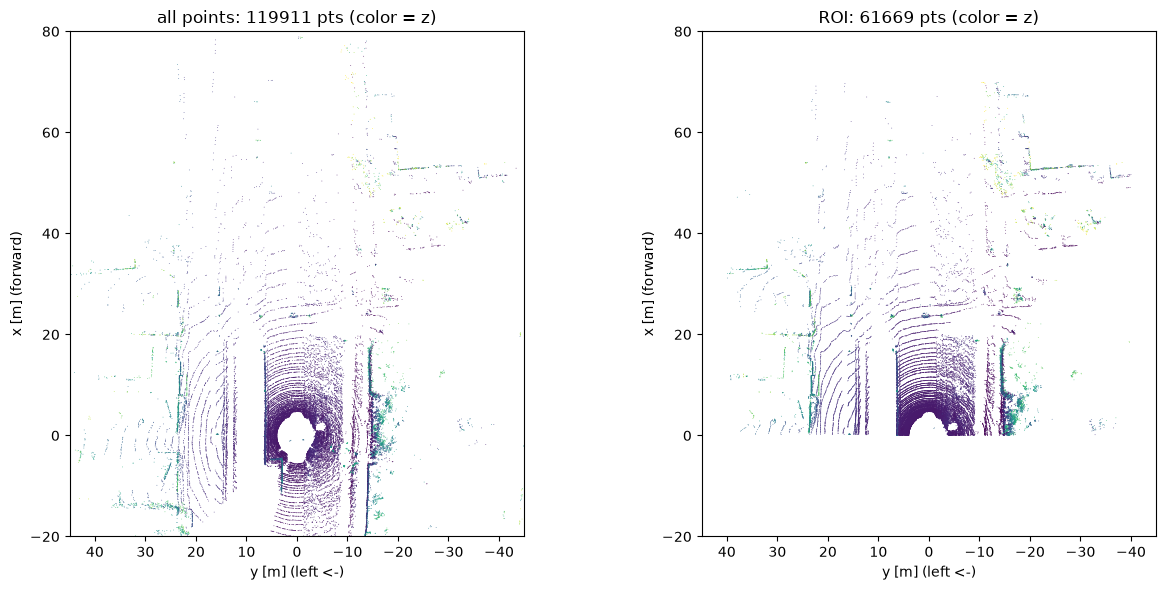

In [3]:
# 직접 작성: ROI 안 점 mask (경계 포함). 좌표는 Velodyne (x 전방, y 좌, z 상, m)
def roi_mask(pc, roi):
    return ((pc[:, 0] >= roi["x_min"]) & (pc[:, 0] <= roi["x_max"])
            & (np.abs(pc[:, 1]) <= roi["y_abs_max"])
            & (pc[:, 2] >= roi["z_min"]) & (pc[:, 2] <= roi["z_max"]))

print("ROI:", F["roi"])
roi = roi_mask(pc_velo, F["roi"])
q_roi = pc_velo[roi]
print(f"전체 {len(pc_velo)} → ROI {roi.sum()} ({roi.mean():.0%}) | ROI 점 x {q_roi[:,0].min():.1f}~{q_roi[:,0].max():.1f}, y {q_roi[:,1].min():.1f}~{q_roi[:,1].max():.1f}, z {q_roi[:,2].min():.2f}~{q_roi[:,2].max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
rng = np.random.default_rng(0)
for ax, (m, title) in zip(axes, [(np.ones(len(pc_velo), bool), "all points"), (roi, "ROI")]):
    q = pc_velo[m]; q = q[rng.choice(len(q), min(len(q), 40000), replace=False)]
    ax.scatter(q[:, 1], q[:, 0], s=0.3, c=q[:, 2], cmap="viridis", vmin=-2, vmax=2, linewidths=0)
    ax.set_xlim(45, -45); ax.set_ylim(-20, 80); ax.set_aspect("equal"); ax.set_title(f"{title}: {m.sum()} pts (color = z)")
    ax.set_xlabel("y [m] (left <-)"); ax.set_ylabel("x [m] (forward)")
plt.tight_layout(); plt.show()

In [4]:
# 검증: 정답지 roi_filter 와 mask 일치
from perceptrack3d.fusion.point_filters import roi_filter                  # 정답지 (검증 전용)
ref = roi_filter(pc_velo, F["roi"])
print("mask 일치:", np.array_equal(roi, ref), "| 점 수", roi.sum(), "vs", ref.sum())

mask 일치: True | 점 수 61669 vs 61669


### 조각 2. 지면 제거 — Open3D `segment_plane` (RANSAC 평면)

- **검색어**: `open3d ransac plane segmentation ground removal`
- **출처**: Open3D 공식 튜토리얼 "Point cloud" › Plane segmentation — https://www.open3d.org/docs/release/tutorial/geometry/pointcloud.html — MIT (원본 노트북 `docs/jupyter/geometry/pointcloud.ipynb`) — 2026-09-08 — `notebooks_2nd/sources/open3d_tutorial/plane_segmentation.py` (원본 노트북 전체는 같은 폴더 `pointcloud.ipynb`)
- **왜 이걸 가져오나**: 2D 박스 아랫변에는 도로 점이 걸린다. 지면을 빼지 않으면 DBSCAN 이 도로를 타고 물체와 뒤 배경을 한 덩어리로 잇고, 지면 점이 중앙값을 아래로 끈다. 튜토리얼이 "가장 큰 평면 하나를 RANSAC 으로 찾는" 예제를 그대로 준다.
- **읽을 때 볼 곳**: 세 인자 `distance_threshold`(평면에서 inlier 로 볼 최대 거리), `ransac_n`(가설마다 뽑는 점 수), `num_iterations`; 반환은 평면 (a, b, c, d) 로 `ax + by + cz + d = 0`, 그리고 inlier 인덱스 리스트.

용어: **RANSAC** = 점 3개를 무작위로 뽑아 평면 가설을 만들고, 그 평면에서 `distance_threshold` 안에 있는 점(inlier) 수를 센 뒤, 반복 중 가장 inlier 가 많은 가설을 고르는 방법. 원점 아래 지면 높이는 x = y = 0 을 대입해 **z = −d / c**. KITTI Velodyne 은 지면 위 1.73 m 에 있으므로 −1.7 근방이면 정상.

In [5]:
# ORIGINAL: Open3D tutorial pointcloud.ipynb :: "Plane segmentation" code cell, MIT
pcd_point_cloud = o3d.data.PCDPointCloud()
pcd = o3d.io.read_point_cloud(pcd_point_cloud.path)

plane_model, inliers = pcd.segment_plane(distance_threshold=0.01,
                                         ransac_n=3,
                                         num_iterations=1000)
[a, b, c, d] = plane_model
print(f"Plane equation: {a:.2f}x + {b:.2f}y + {c:.2f}z + {d:.2f} = 0")

inlier_cloud = pcd.select_by_index(inliers)
inlier_cloud.paint_uniform_color([1.0, 0, 0])
outlier_cloud = pcd.select_by_index(inliers, invert=True)
# o3d.visualization.draw_geometries([inlier_cloud, outlier_cloud],      # CHANGED: Open3D 창 금지 (headless)
#                                   zoom=0.8,
#                                   front=[-0.4999, -0.1659, -0.8499],
#                                   lookat=[2.1813, 2.0619, 2.0999],
#                                   up=[0.1204, -0.9852, 0.1215])
print("demo:", len(pcd.points), "points,", len(inliers), "inliers")

Plane equation: -0.06x + -0.10y + 0.99z + -1.05 = 0
demo: 113662 points, 56716 inliers


시드 없이 3번:
  run0: inliers 41171  plane [a,b,c,d] = [    -0.0031     -0.0088           1      1.6773]  원점 아래 지면 z = -1.677 m
  run1: inliers 39636  plane [a,b,c,d] = [     0.0028     -0.0097      0.9999      1.6479]  원점 아래 지면 z = -1.648 m
  run2: inliers 40307  plane [a,b,c,d] = [    -0.0011     -0.0105      0.9999      1.6801]  원점 아래 지면 z = -1.680 m
o3d.utility.random.seed(0) 을 매번 걸고 3번:
  run0: inliers 41074  plane [a,b,c,d] = [    -0.0027      -0.009           1      1.6787]  원점 아래 지면 z = -1.679 m
  run1: inliers 41074  plane [a,b,c,d] = [    -0.0027      -0.009           1      1.6787]  원점 아래 지면 z = -1.679 m
  run2: inliers 41074  plane [a,b,c,d] = [    -0.0027      -0.009           1      1.6787]  원점 아래 지면 z = -1.679 m

ROI 61669 → 지면 41074 제거 → 남은 점 20595 | 법선 z 성분 1.0000 (1 에 가까우면 수평면)


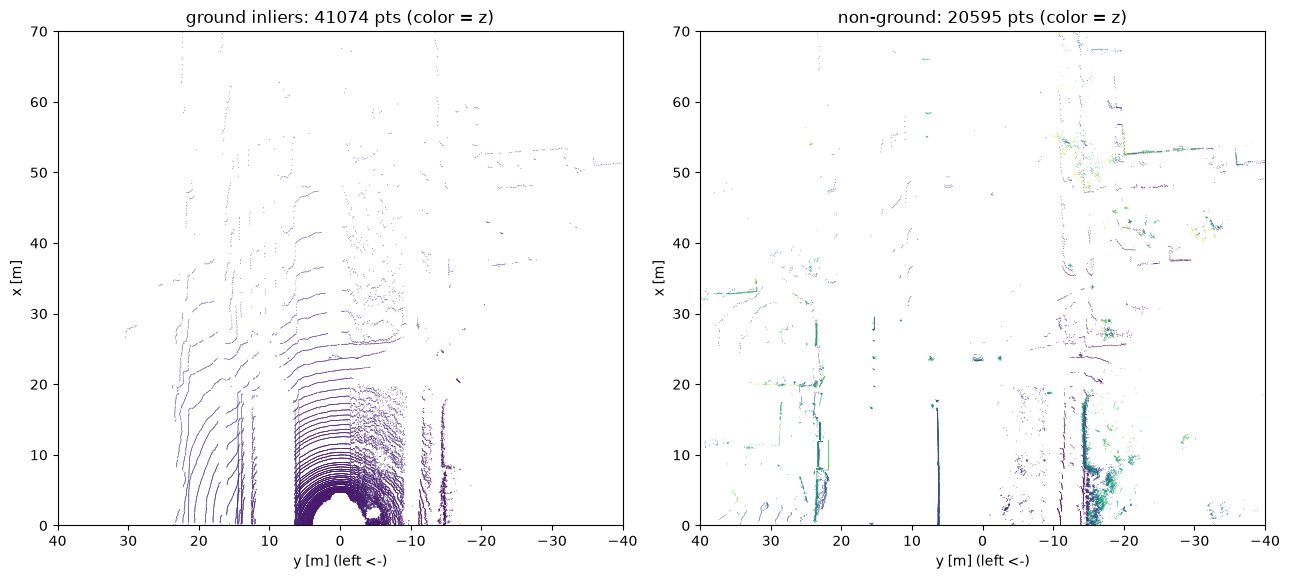

In [6]:
# 우리 ROI 점군에 적용. 설정값은 configs/kitti.yaml fusion.ground (distance_threshold 0.2 m, ransac_n 3, num_iterations 200)
G = F["ground"]
pcd = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(q_roi))          # CHANGED: 파일 대신 numpy (M, 3) 로 점군 생성

def run_o3d_plane(seed=None):
    if seed is not None:
        o3d.utility.random.seed(seed)
    plane_model, inliers = pcd.segment_plane(distance_threshold=G["distance_threshold"], ransac_n=G["ransac_n"], num_iterations=G["num_iterations"])
    return np.asarray(plane_model), np.asarray(inliers)

print("시드 없이 3번:")
for t in range(3):
    pl, inl = run_o3d_plane()
    print(f"  run{t}: inliers {len(inl)}  plane [a,b,c,d] = {np.round(pl, 4)}  원점 아래 지면 z = {-pl[3]/pl[2]:+.3f} m")
print("o3d.utility.random.seed(0) 을 매번 걸고 3번:")
for t in range(3):
    pl, inl = run_o3d_plane(seed=0)
    print(f"  run{t}: inliers {len(inl)}  plane [a,b,c,d] = {np.round(pl, 4)}  원점 아래 지면 z = {-pl[3]/pl[2]:+.3f} m")

plane_o3d, inl_o3d = run_o3d_plane(seed=0)                                 # 이후 조각은 이 (시드 건) 결과를 쓴다
ground = np.zeros(len(q_roi), bool); ground[inl_o3d] = True
keep = np.zeros(len(pc_velo), bool); keep[np.flatnonzero(roi)[~ground]] = True   # 원본 인덱스 기준 "ROI 안 ∧ 비지면"
print(f"\nROI {len(q_roi)} → 지면 {ground.sum()} 제거 → 남은 점 {keep.sum()} | 법선 z 성분 {abs(plane_o3d[2]):.4f} (1 에 가까우면 수평면)")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (m, title) in zip(axes, [(ground, "ground inliers"), (~ground, "non-ground")]):
    q = q_roi[m]; q = q[rng.choice(len(q), min(len(q), 40000), replace=False)]
    ax.scatter(q[:, 1], q[:, 0], s=0.3, c=q[:, 2], cmap="viridis", vmin=-2, vmax=2, linewidths=0)
    ax.set_xlim(40, -40); ax.set_ylim(0, 70); ax.set_aspect("equal"); ax.set_title(f"{title}: {m.sum()} pts (color = z)")
    ax.set_xlabel("y [m] (left <-)"); ax.set_ylabel("x [m]")
plt.tight_layout(); plt.show()

**관찰**: 시드를 걸지 않으면 실행마다 inlier 수가 수백~수천 개씩 다르다 (RANSAC 이 뽑는 3점 표본이 다르니 당연하다). **시드를 걸어도 항상 같지는 않다** — 우리가 반복 실행해 본 결과, 같은 프로세스 안에서 연속 호출이 달라진 적도 있고, 같은 프로세스에서는 같다가 프로세스를 바꾸면 달라진 적도 있다 (Open3D 0.19 의 RANSAC 은 가설을 병렬로 평가해 시드가 순서를 완전히 고정하지 못한다). 이 노트북을 다시 실행하면 위 숫자도, 뒤 조각의 결과도 달라질 수 있다.

정답지는 그래서 numpy 로 다시 썼다 (`point_filters.py::ransac_plane`, 시드 고정 → 완전히 결정적, 테스트로 확인). 원문 인용:

```python
def ransac_plane(points_xyz, distance_threshold, num_iterations, seed=RANSAC_SEED, chunk=50, max_score_points=12000):
    p = np.asarray(points_xyz, dtype=np.float64)
    N = len(p)
    rng = np.random.default_rng(seed)
    score = p if N <= max_score_points else p[rng.choice(N, max_score_points, replace=False)]
    score32 = score.astype(np.float32)
    best_count, best_plane = -1, None
    for start in range(0, num_iterations, chunk):
        k = min(chunk, num_iterations - start)
        idx = rng.integers(0, N, size=(k, 3))
        a, b, c = p[idx[:, 0]], p[idx[:, 1]], p[idx[:, 2]]
        nrm = np.cross(b - a, c - a)                                  # (k, 3) 법선 (정규화 전)
        length = np.linalg.norm(nrm, axis=1)
        ok = length > 1e-9                                            # 세 점이 한 직선 위면 평면이 정의되지 않음
        if not ok.any():
            continue
        nrm = nrm[ok] / length[ok, None]
        d = -np.einsum("ij,ij->i", nrm, a[ok])                        # (k',)
        dist = np.abs(score32 @ nrm.T.astype(np.float32) + d.astype(np.float32))   # (M, k') 점-평면 거리
        counts = (dist <= distance_threshold).sum(axis=0)
        j = int(np.argmax(counts))
        if counts[j] > best_count:
            best_count, best_plane = int(counts[j]), np.append(nrm[j], d[j])
    if best_plane is None:
        return np.full(4, np.nan), np.zeros(N, dtype=bool)
    # 최소제곱 재적합: inlier 점의 중심을 지나고, 퍼짐이 가장 작은 방향(최소 특이벡터) 이 법선
    inl = np.abs(p @ best_plane[:3] + best_plane[3]) <= distance_threshold
    q = p[inl]
    centroid = q.mean(axis=0)
    _, _, vt = np.linalg.svd(q - centroid, full_matrices=False)
    nrm = vt[-1]
    plane = np.append(nrm, -nrm @ centroid)
    inl = np.abs(p @ plane[:3] + plane[3]) <= distance_threshold
    return plane, inl
```
Open3D 와 다른 점: (1) `np.random.default_rng(seed)` 로 표본을 뽑아 결정적, (2) 가설 50개를 행렬곱 한 번으로 평가, (3) 마지막에 inlier 로 SVD 최소제곱 재적합. 아래 검증 셀에서 두 평면이 얼마나 다른지, 그 차이가 **멀리서** 얼마나 커지는지 본다.

In [7]:
# 검증: 정답지 remove_ground (numpy RANSAC, 기본 method) 와 비교
from perceptrack3d.fusion.point_filters import remove_ground                # 정답지 (검증 전용)
non_ground_np, plane_np = remove_ground(q_roi, F["ground"])
non_ground_np2, plane_np2 = remove_ground(q_roi, F["ground"])
print(f"정답지 numpy RANSAC: 지면 {(~non_ground_np).sum()}  plane {np.round(plane_np, 4)}  z0 {-plane_np[3]/plane_np[2]:+.3f} m | 두 번 실행 동일: {np.array_equal(non_ground_np, non_ground_np2)}")
print(f"Open3D (seed 0)   : 지면 {ground.sum()}  plane {np.round(plane_o3d, 4)}  z0 {-plane_o3d[3]/plane_o3d[2]:+.3f} m")
print(f"지면/비지면 판정이 다른 점: {(ground != ~non_ground_np).sum()} / {len(q_roi)}")

# 두 평면의 높이 차이는 거리에 비례해 커진다: z_plane(x, y) = -(a x + b y + d) / c
def plane_z(pl, x, y): return -(pl[0] * x + pl[1] * y + pl[3]) / pl[2]
for (x, y, where) in [(0, 0, "원점 아래"), (25, 0, "det0 앞차 (25 m)"), (37, -28, "det6 (37 m, 우측 28 m)"), (49, 21, "det2 (49 m, 좌측 21 m)")]:
    print(f"  {where:<22} 지면 높이 numpy {plane_z(plane_np, x, y):+.3f}  o3d {plane_z(plane_o3d, x, y):+.3f}  차이 {abs(plane_z(plane_np, x, y) - plane_z(plane_o3d, x, y)):.3f} m  (threshold {G['distance_threshold']} m)")

정답지 numpy RANSAC: 지면 39952  plane [    -0.0024     -0.0061           1      1.6605]  z0 -1.661 m | 두 번 실행 동일: True
Open3D (seed 0)   : 지면 41074  plane [    -0.0027      -0.009           1      1.6787]  z0 -1.679 m
지면/비지면 판정이 다른 점: 1952 / 61669
  원점 아래                  지면 높이 numpy -1.661  o3d -1.679  차이 0.018 m  (threshold 0.2 m)
  det0 앞차 (25 m)         지면 높이 numpy -1.600  o3d -1.612  차이 0.012 m  (threshold 0.2 m)
  det6 (37 m, 우측 28 m)   지면 높이 numpy -1.743  o3d -1.832  차이 0.089 m  (threshold 0.2 m)
  det2 (49 m, 좌측 21 m)   지면 높이 numpy -1.414  o3d -1.360  차이 0.054 m  (threshold 0.2 m)


두 평면은 원점에서는 몇 mm 차이지만 **법선 기울기 차이(0.005 rad 정도) 가 40 m 밖에서는 0.1~0.2 m** 로 벌어져 `distance_threshold`(0.2 m) 와 같은 크기가 된다. 즉 먼 차의 하부 점이 한쪽에서는 지면, 다른 쪽에서는 물체로 분류된다. 이 차이가 조각 4 에서 클러스터 선택을 뒤집는 것을 보게 된다.

### 조각 3. DBSCAN — Open3D `cluster_dbscan` (+ scikit-learn 교차 검증)

- **검색어**: `open3d dbscan point cloud clustering eps min_points`, `sklearn DBSCAN eps min_samples`
- **출처**: Open3D 공식 튜토리얼 "Point cloud" › DBSCAN clustering — https://www.open3d.org/docs/release/tutorial/geometry/pointcloud.html — MIT — 2026-09-08 — `notebooks_2nd/sources/open3d_tutorial/dbscan_clustering.py`. 교차 검증: scikit-learn `sklearn.cluster.DBSCAN` 문서 — https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html — BSD-3-Clause — `notebooks_2nd/sources/sklearn_docs/DBSCAN.txt`
- **왜 이걸 가져오나**: 프러스텀(축소 박스 ∧ ROI ∧ 비지면) 안에는 "물체 덩어리 + 뒤 배경 덩어리 + 흩어진 점" 이 있다. DBSCAN 은 덩어리 수를 미리 정하지 않고 밀도로 나누며 흩어진 점은 noise(−1) 로 표시한다. 같은 알고리즘의 다른 구현(scikit-learn) 이 같은 결과를 내면 파라미터 의미를 제대로 이해한 것이다.
- **읽을 때 볼 곳**: Open3D — "`eps` defines the distance to neighbors in a cluster and `min_points` defines the minimum number of points required to form a cluster … label `-1` indicates noise". scikit-learn — `min_samples` "The number of samples … for a point to be considered as a core point. **This includes the point itself.**"

용어: **DBSCAN** (Ester et al., KDD 1996) — 반경 `eps` 안에 `min_points` 개 이상의 이웃이 있는 점을 핵심점으로 삼고, 핵심점끼리 `eps` 안에서 이어지면 같은 덩어리. 파라미터 근거(정답지 스윕): HDL-64 의 링 간격이 60 m 에서 약 0.4 m 라 `eps` 0.6 은 먼 차를 두 조각으로 나눴다 → 0.8; `min_points` 8 이면 5~7 점짜리 먼 차가 전부 no_cluster → 5.

In [8]:
# ORIGINAL: Open3D tutorial pointcloud.ipynb :: "DBSCAN clustering" code cell, MIT
ply_point_cloud = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(ply_point_cloud.path)

with o3d.utility.VerbosityContextManager(
        o3d.utility.VerbosityLevel.Debug) as cm:
    labels = np.array(
        pcd.cluster_dbscan(eps=0.02, min_points=10, print_progress=True))

max_label = labels.max()
print(f"point cloud has {max_label + 1} clusters")
colors = plt.get_cmap("tab20")(labels / (max_label if max_label > 0 else 1))
colors[labels < 0] = 0
pcd.colors = o3d.utility.Vector3dVector(colors[:, :3])
# o3d.visualization.draw_geometries([pcd],                                # CHANGED: Open3D 창 금지 (headless)
#                                   zoom=0.455,
#                                   front=[-0.4999, -0.1659, -0.8499],
#                                   lookat=[2.1813, 2.0619, 2.0999],
#                                   up=[0.1204, -0.9852, 0.1215])

[Open3D DEBUG] Precompute neighbors.
[Open3D DEBUG] Done Precompute neighbors.
[Open3D DEBUG] Compute Clusters


[Open3D DEBUG] Done Compute Clusters: 10
point cloud has 10 clusters
Precompute neighbors.[========================================] 100%


det   축소박스   ∧ROI∧비지면   클러스터 noise  각 클러스터 (n, 깊이 중앙값 m)
  0     97         84      1     0  c0: (84, 23.1)
  1    112         70      3     9  c0: (19, 27.4), c1: (22, 23.9), c2: (20, 36.8)
  2     30         21      1     2  c0: (19, 47.2)
  3     20         10      1     3  c0: (7, 47.7)
  4     25         25      3     2  c0: (6, 37.3), c1: (5, 25.9), c2: (12, 34.2)
  5     13         13      1     0  c0: (13, 47.7)
  6     83         57      2     4  c0: (6, 51.1), c1: (47, 37.2)


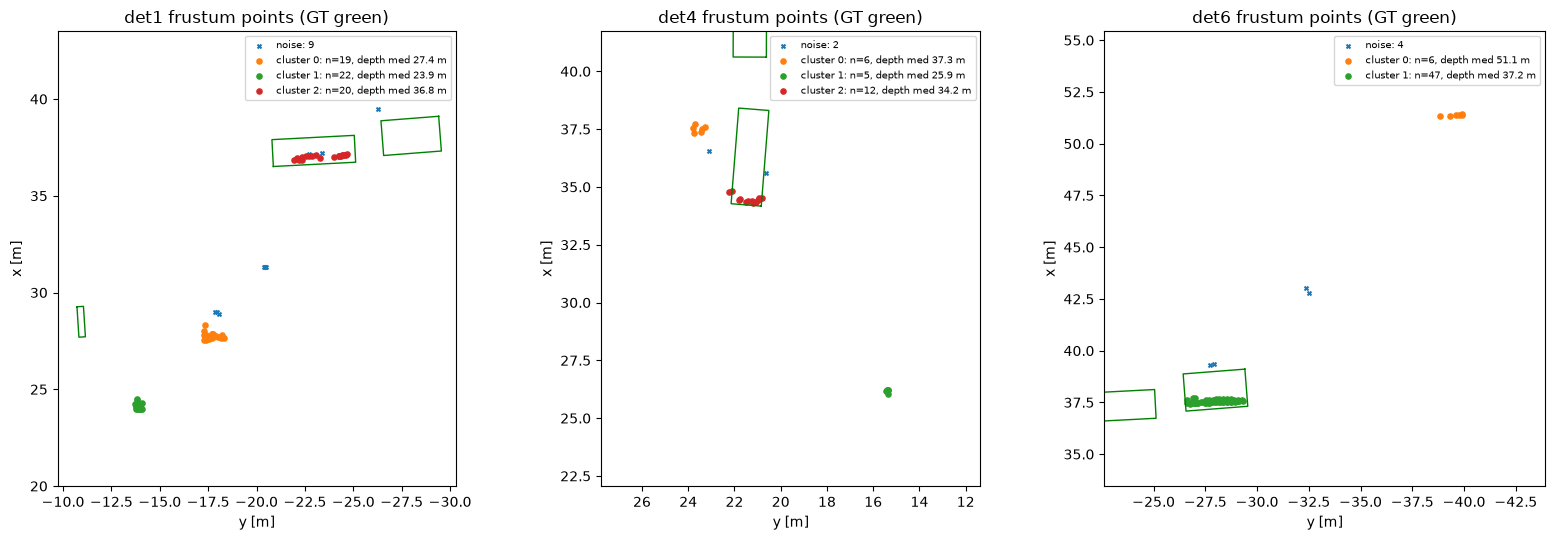

In [9]:
# 프러스텀 점 = 축소 박스 안 ∧ ROI ∧ 비지면 → 검출마다 DBSCAN (eps 0.8 m, min_points 5)
C = F["cluster"]
frus = [s[keep[s]] for s in box_sel]                                       # 검출별 원본 인덱스
labels_all = []
print(f"{'det':>3} {'축소박스':>6} {'∧ROI∧비지면':>10} {'클러스터':>6} {'noise':>5}  각 클러스터 (n, 깊이 중앙값 m)")
for k, sel in enumerate(frus):
    if len(sel) == 0:
        labels_all.append(np.zeros(0, int)); print(f"{k:>3} {len(box_sel[k]):>6} {0:>10}"); continue
    pcd_k = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(pc_velo[sel]))   # CHANGED: numpy 점 → Open3D 점군
    lab = np.array(pcd_k.cluster_dbscan(eps=C["eps"], min_points=C["min_points"], print_progress=False))   # CHANGED: 우리 파라미터, 진행 표시 끔
    labels_all.append(lab)
    info = ", ".join(f"c{c}: ({(lab == c).sum()}, {np.median(depth_all[sel][lab == c]):.1f})" for c in range(lab.max() + 1))
    print(f"{k:>3} {len(box_sel[k]):>6} {len(sel):>10} {lab.max() + 1:>6} {(lab == -1).sum():>5}  {info}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, k in zip(axes, [1, 4, 6]):
    sel, lab = frus[k], labels_all[k]; q = pc_velo[sel]
    for c in sorted(set(lab)):
        m = lab == c
        ax.scatter(q[m, 1], q[m, 0], s=14 if c >= 0 else 8, marker="o" if c >= 0 else "x",
                   label=f"cluster {c}: n={m.sum()}, depth med {np.median(depth_all[sel][m]):.1f} m" if c >= 0 else f"noise: {m.sum()}")
    for b in gts:
        cc = bev_corners(b.center, b.size, b.yaw); cc = np.vstack([cc, cc[:1]]); ax.plot(cc[:, 1], cc[:, 0], "g-", lw=1)
    ax.set_xlim(q[:, 1].max() + 4, q[:, 1].min() - 4); ax.set_ylim(q[:, 0].min() - 4, q[:, 0].max() + 4)
    ax.set_aspect("equal"); ax.legend(fontsize=7); ax.set_title(f"det{k} frustum points (GT green)"); ax.set_xlabel("y [m]"); ax.set_ylabel("x [m]")
plt.tight_layout(); plt.show()

In [10]:
# 검증 1: 정답지 cluster_points (Open3D) 와 라벨 일치
from perceptrack3d.fusion.point_filters import cluster_points              # 정답지 (검증 전용)
# 검증 2: 같은 알고리즘의 다른 구현 — scikit-learn
# ORIGINAL: sklearn.cluster.DBSCAN docs :: Examples, BSD-3-Clause
from sklearn.cluster import DBSCAN
X = np.array([[1, 2], [2, 2], [2, 3],
              [8, 7], [8, 8], [25, 80]])
clustering = DBSCAN(eps=3, min_samples=2).fit(X)
print(clustering.labels_)              # array([ 0,  0,  0,  1,  1, -1])

for k, sel in enumerate(frus):
    if len(sel) == 0: continue
    ref = cluster_points(pc_velo[sel], C)
    sk = DBSCAN(eps=C["eps"], min_samples=C["min_points"]).fit(pc_velo[sel]).labels_      # min_samples ↔ min_points (자기 자신 포함)
    print(f"det{k}: 정답지와 라벨 일치 {np.array_equal(labels_all[k], ref)} | sklearn 과 라벨 일치 {np.array_equal(labels_all[k], sk)} "
          f"(클러스터 수 o3d {labels_all[k].max() + 1} / sk {sk.max() + 1}, noise {(labels_all[k] == -1).sum()} / {(sk == -1).sum()})")

[ 0  0  0  1  1 -1]
det0: 정답지와 라벨 일치 True | sklearn 과 라벨 일치 True (클러스터 수 o3d 1 / sk 1, noise 0 / 0)
det1: 정답지와 라벨 일치 True | sklearn 과 라벨 일치 True (클러스터 수 o3d 3 / sk 3, noise 9 / 9)
det2: 정답지와 라벨 일치 True | sklearn 과 라벨 일치 True (클러스터 수 o3d 1 / sk 1, noise 2 / 2)
det3: 정답지와 라벨 일치 True | sklearn 과 라벨 일치 True (클러스터 수 o3d 1 / sk 1, noise 3 / 3)
det4: 정답지와 라벨 일치 True | sklearn 과 라벨 일치 True (클러스터 수 o3d 3 / sk 3, noise 2 / 2)
det5: 정답지와 라벨 일치 True | sklearn 과 라벨 일치 True (클러스터 수 o3d 1 / sk 1, noise 0 / 0)
det6: 정답지와 라벨 일치 True | sklearn 과 라벨 일치 True (클러스터 수 o3d 2 / sk 2, noise 4 / 4)


Open3D 와 scikit-learn 이 **라벨 번호까지** 같다 — 둘 다 점 순서대로 핵심점을 만나면서 클러스터 번호를 매기기 때문이다. 알고리즘이 결정적이므로 (지면 제거와 달리) 라이브러리를 바꿔도 결과가 같다. 다른 순서로 점을 넣으면 번호만 바뀐다.

### 조각 4. 클러스터 선택 규칙 — largest vs nearest (직접 작성)

- **검색어**: (검색해도 정해진 답이 없다) `frustum point cloud which cluster is the object nearest largest`
- **출처**: 없음 — 직접 작성. Frustum PointNets 는 이 단계를 학습된 segmentation PointNet 으로 대체한다 (§4.2). 정답지 팀은 두 규칙을 설정(`cluster_select`) 으로 남겼다.
- **왜 이걸 가져오나**: 프러스텀 안 덩어리가 여러 개일 때 어느 것이 물체인가. **largest**(점 수 최대) 는 "축소 박스 안에서 물체가 가장 큰 덩어리" 라는 가정, **nearest**(깊이 중앙값 최소) 는 "배경은 항상 더 멀다" 는 가정이다. 둘 다 깨지는 장면이 있다.
- **읽을 때 볼 곳**: 정답지 `frustum_fusion.py::_select_cluster` 독스트링 (검증 셀에서 비교).

In [11]:
# 직접 작성: 두 선택 규칙. labels (M,) int (−1 = noise), depth (M,) 카메라 앞 깊이
def select_largest(labels, depth):
    ids = np.unique(labels[labels >= 0])
    cnt = np.array([(labels == k).sum() for k in ids])
    med = np.array([np.median(depth[labels == k]) for k in ids])
    best = np.flatnonzero(cnt == cnt.max())
    return int(ids[best[np.argmin(med[best])]])                            # 동률이면 가까운 쪽

def select_nearest(labels, depth, min_ratio=0.0):
    ids = np.unique(labels[labels >= 0])
    cnt = np.array([(labels == k).sum() for k in ids])
    med = np.array([np.median(depth[labels == k]) for k in ids])
    ok = np.flatnonzero(cnt >= min_ratio * cnt.max())                     # 너무 작은 덩어리(노이즈) 는 후보에서 제외
    return int(ids[ok[np.argmin(med[ok])]])

print("예: labels [0,0,0,1,1,-1], depth [30,31,30,20,21,50] → largest", select_largest(np.array([0,0,0,1,1,-1]), np.array([30,31,30,20,21,50.])),
      "| nearest", select_nearest(np.array([0,0,0,1,1,-1]), np.array([30,31,30,20,21,50.])))

예: labels [0,0,0,1,1,-1], depth [30,31,30,20,21,50] → largest 0 | nearest 1


In [12]:
print(f"{'det':>3} {'largest→(n, depth)':>20} {'nearest→(n, depth)':>20} {'nearest r=0.3':>15} {'가장 가까운 GT x':>14}  판단")
chosen = {}                                                                 # det → largest 로 고른 클러스터의 원본 인덱스
for k, (sel, lab) in enumerate(zip(frus, labels_all)):
    if len(lab) == 0 or lab.max() < 0:
        print(f"{k:>3} {'(클러스터 없음)':>20}"); continue
    dd = depth_all[sel]
    a, b, b3 = select_largest(lab, dd), select_nearest(lab, dd), select_nearest(lab, dd, 0.3)
    chosen[k] = sel[lab == a]
    fmt = lambda c: f"c{c} ({(lab == c).sum()}, {np.median(dd[lab == c]):.1f})"
    g, dist = nearest_gt(np.median(pc_velo[sel[lab == a]], axis=0))
    verdict = "같음" if a == b else ("largest 가 GT 쪽" if abs(np.median(dd[lab == a]) - g.center[0]) < abs(np.median(dd[lab == b]) - g.center[0]) else "nearest 가 GT 쪽")
    print(f"{k:>3} {fmt(a):>20} {fmt(b):>20} {fmt(b3):>15} {g.center[0]:14.2f}  {verdict}")

det   largest→(n, depth)   nearest→(n, depth)   nearest r=0.3    가장 가까운 GT x  판단
  0        c0 (84, 23.1)        c0 (84, 23.1)   c0 (84, 23.1)          25.45  같음
  1        c1 (22, 23.9)        c1 (22, 23.9)   c1 (22, 23.9)          28.49  같음
  2        c0 (19, 47.2)        c0 (19, 47.2)   c0 (19, 47.2)          49.22  같음
  3         c0 (7, 47.7)         c0 (7, 47.7)    c0 (7, 47.7)          49.25  같음
  4        c2 (12, 34.2)         c1 (5, 25.9)    c1 (5, 25.9)          36.29  largest 가 GT 쪽
  5        c0 (13, 47.7)        c0 (13, 47.7)   c0 (13, 47.7)          49.25  같음
  6        c1 (47, 37.2)        c1 (47, 37.2)   c1 (47, 37.2)          38.09  같음


이 실행(시드 0 의 Open3D 지면) 에서는 어느 검출이 규칙에 따라 갈리는지 위 표가 말해 준다. 정답지 팀의 관찰:
- 이 시퀀스 전체(297 프레임, 2 m 매칭) 에서는 **largest 926 vs nearest 884** 매칭 — 가까운 곳의 작은 덩어리(지면 잔여·기둥·풀) 가 물체보다 자주 나타나 nearest 가 진다 (det4 의 5점짜리 25.9 m 덩어리가 그 예).
- 반대로 **배경이 물체보다 큰 덩어리**면 largest 가 틀린다 (det6: 37 m 차 뒤 51 m 배경). 어느 쪽이 맞는지는 지면 평면이 차 하부 점을 얼마나 깎았는지에 달려 있어서, 조각 2 의 평면 차이가 그대로 여기서 드러난다.

In [13]:
# 검증 1: 정답지 _select_cluster 와 같은 클러스터를 고르는가
from perceptrack3d.fusion.frustum_fusion import _select_cluster, fuse_frame_clustered   # 정답지 (검증 전용)
for k, (sel, lab) in enumerate(zip(frus, labels_all)):
    if len(lab) == 0 or lab.max() < 0: continue
    dd = depth_all[sel]
    print(f"det{k}: largest {select_largest(lab, dd)} vs {_select_cluster(lab, dd, 'largest')} | nearest {select_nearest(lab, dd)} vs {_select_cluster(lab, dd, 'nearest')} "
          f"| nearest r=0.3 {select_nearest(lab, dd, 0.3)} vs {_select_cluster(lab, dd, 'nearest', 0.3)}")

# 검증 2: 지면 평면이 선택을 뒤집는다 — 정답지 fuse_frame_clustered 를 numpy 지면(기본) 과 Open3D 지면(method: open3d) 으로 돌려 비교
cfg_o3d = copy.deepcopy(cfg); cfg_o3d["fusion"]["ground"]["method"] = "open3d"
ref_np = fuse_frame_clustered(pts, dets, calib, (H, W), cfg)
ref_o3d = fuse_frame_clustered(pts, dets, calib, (H, W), cfg_o3d)
print(f"\n{'det':>3} {'numpy 지면: n, x':>18} {'o3d 지면: n, x':>18} {'GT x':>7}  비고")
for k, (a, b) in enumerate(zip(ref_np, ref_o3d)):
    xa = f"{a.n_points:3d}, {a.center[0]:6.2f}" if a.center is not None else f"{a.status}"
    xb = f"{b.n_points:3d}, {b.center[0]:6.2f}" if b.center is not None else f"{b.status}"
    g = nearest_gt(a.center if a.center is not None else (b.center if b.center is not None else np.zeros(3)))[0]
    note = "" if (a.center is None or b.center is None or abs(a.center[0] - b.center[0]) < 0.5) else "← 지면 평면 차이로 클러스터가 달라짐"
    print(f"{k:>3} {xa:>18} {xb:>18} {g.center[0]:7.2f}  {note}")

det0: largest 0 vs 0 | nearest 0 vs 0 | nearest r=0.3 0 vs 0
det1: largest 1 vs 1 | nearest 1 vs 1 | nearest r=0.3 1 vs 1
det2: largest 0 vs 0 | nearest 0 vs 0 | nearest r=0.3 0 vs 0
det3: largest 0 vs 0 | nearest 0 vs 0 | nearest r=0.3 0 vs 0
det4: largest 2 vs 2 | nearest 1 vs 1 | nearest r=0.3 1 vs 1
det5: largest 0 vs 0 | nearest 0 vs 0 | nearest r=0.3 0 vs 0
det6: largest 1 vs 1 | nearest 1 vs 1 | nearest r=0.3 1 vs 1

det     numpy 지면: n, x       o3d 지면: n, x    GT x  비고
  0         84,  24.92         84,  24.92   25.45  
  1         34,  37.93         22,  25.72   37.32  ← 지면 평면 차이로 클러스터가 달라짐
  2         28,  48.68         19,  48.87   49.22  
  3          7,  49.86          7,  49.86   49.25  
  4         12,  35.72         12,  35.72   36.29  
  5            invalid            invalid   25.45  
  6         45,  38.45         47,  38.45   38.09  


정답지 노트북의 6.2 절 마크다운은 "det6 은 largest 가 51 m 배경을 고른다" 고 적혀 있는데, 정답지 자신의 출력(6.3 절 표) 에서는 det6 가 38.45 m 로 맞는다. 정답지가 Open3D 지면(초기 구현) 을 쓰던 때의 관찰이고, numpy RANSAC 으로 바꾼 뒤에는 차 하부 점이 덜 깎여 largest 가 차를 고른 것이다. 이 노트북에서도 지면 평면에 따라 det1 또는 det6 의 선택이 뒤집히는 것을 조각 4 B 셀(우리 Open3D 지면) 과 위 표(정답지 Open3D 모드) 에서 볼 수 있다 — 어느 검출이 뒤집히는지는 실행마다 다르다. **같은 코드·같은 파라미터라도 앞 단계(지면) 가 조금 바뀌면 뒤 단계(선택) 결과가 뒤집힐 수 있다** — 문서와 출력이 어긋나면 출력을 믿고 원인을 찾는다.

### 조각 5. 표면→중심 오프셋 — 직접 작성 (출처 없음)

- **검색어**: `lidar visible surface bias object center offset` — 검색으로는 바로 나오지 않는다. 정답지 팀이 GT 비교에서 고안했다.
- **출처**: 없음. 크기 prior 는 KITTI raw tracklet GT (`readme.txt` "Tracklet Labels": 각 tracklet 에 h, w, l) 에서 직접 계산 — KITTI (연구용).
- **왜 이걸 가져오나**: 05 조각 5 에서 본 편차 dx ≈ −(센서를 향한 치수)/2 는 통계로 못 없앤다. "물체가 얼마나 깊은지" 를 외부 정보(클래스별 길이 prior) 로 넣어 시선 방향으로 밀어야 한다.

**AI 이전이라면 어떻게 알아챘을까**: (1) GT 와 BEV 로 겹쳐 보니 빨간 × 가 늘 초록 박스의 **센서 쪽 면**에 붙어 있다 (05 조각 5 그림). (2) 편차의 크기가 정면 차 ≈ 2 m, 옆 차 ≈ 0.6 m 로 **차의 길이/폭의 절반**과 일치한다. (3) 그러면 "보이는 면에서 물체 깊이의 절반만큼 안쪽" 이 중심이다. 얼마나 깊은지는 이미 보이는 만큼(점의 퍼짐) 을 빼고 클래스 prior 로 채운다.

```
u       = c_xy / |c_xy|                 센서(원점) → 물체 BEV 단위벡터 (시선 방향)
extent  = max(p·u) − min(p·u)           클러스터 점을 u 에 투영한 퍼짐 = 이미 보이는 깊이
push    = max(0, half_depth[class] − extent / 2)
c_xy   += u · push                      (z 는 그대로)
```

In [14]:
# 직접 작성 1: 클래스별 크기 prior — tracklet GT 의 (l, w, h) 평균. YOLO 클래스명(car, …) 과 KITTI objectType(Car, Van, …) 이 다름에 주의.
tr = load_tracklets(ds.tracklets_path)
print(f"{'objectType':<12} {'n':>3} {'mean l':>7} {'mean w':>7} {'mean h':>7} {'l/2':>5}")
for t_type in sorted(set(t["object_type"] for t in tr)):
    v = np.array([(t["l"], t["w"], t["h"]) for t in tr if t["object_type"] == t_type])
    print(f"{t_type:<12} {len(v):>3} {v[:, 0].mean():7.2f} {v[:, 1].mean():7.2f} {v[:, 2].mean():7.2f} {v[:, 0].mean() / 2:5.2f}")
HALF = F["surface_offset"]["half_depth_m"]                                 # 설정값 (car 2.0 = KITTI Car 길이 ≈ 4 m 의 절반)
print("설정 half_depth_m:", HALF)

# 직접 작성 2: 표면 중앙값 center (3,) 를 BEV 시선 방향으로 밀기. pts (K, 3) = 클러스터 점, half = 클래스 prior (m)
def surface_offset(center, pts, half):
    c = np.array(center, dtype=np.float64)
    r = np.linalg.norm(c[:2])
    if half <= 0 or r < 1e-6:
        return c
    u = c[:2] / r                                                          # 센서 → 물체 단위벡터
    along = pts[:, :2] @ u                                                 # 점을 시선 방향에 투영
    extent = along.max() - along.min()                                     # 이미 보이는 깊이
    c[:2] += u * max(0.0, half - extent / 2)
    return c

print("예: 정면 15 m 에 x 방향 퍼짐 0.4 m 인 차 →", surface_offset([15, 0, -1], np.array([[14.8, -0.8, -1], [15.2, 0.8, -1]]), 2.0))

objectType     n  mean l  mean w  mean h   l/2
Car           33    3.85    1.59    1.62  1.93
Cyclist        1    1.57    0.34    1.64  0.79
Truck          1    8.69    2.39    3.34  4.35
Van            1    6.86    2.22    2.84  3.43
설정 half_depth_m: {'car': 2.0, 'truck': 3.0, 'bus': 4.0, 'person': 0.35, 'bicycle': 0.85, 'motorcycle': 1.0}
예: 정면 15 m 에 x 방향 퍼짐 0.4 m 인 차 → [       16.8           0          -1]


In [15]:
print(f"{'det':>3} {'n':>3} {'extent':>6} {'push':>5} {'x before':>8} {'x after':>7} {'GT x':>7} {'GT':>5} {'BEV err before':>14} {'after':>6}")
offset_centers = {}
for k, sel in chosen.items():
    q = pc_velo[sel]
    c0 = np.median(q, axis=0)                                              # 표면 위 중앙값
    c1 = surface_offset(c0, q, HALF.get(dets[k].class_name, 0.0))
    offset_centers[k] = c1
    g, dist = nearest_gt(c1)
    u = c0[:2] / np.linalg.norm(c0[:2]); along = q[:, :2] @ u
    note = "" if dist <= 3.0 else "   ← 3 m 안에 GT 없음 (라벨 없는 차량·오검출 또는 클러스터 오선택)"
    print(f"{k:>3} {len(sel):>3} {along.max() - along.min():6.2f} {np.linalg.norm(c1 - c0):5.2f} {c0[0]:8.2f} {c1[0]:7.2f} {g.center[0]:7.2f} gt{g.tracklet_id:<3} "
          f"{np.linalg.norm(c0[:2] - g.center[:2]):14.2f} {np.linalg.norm(c1[:2] - g.center[:2]):6.2f}{note}")
print("\n오프셋은 '클러스터가 물체' 일 때만 의미가 있다. 배경 덩어리를 골랐으면(예: det6 가 51 m 를 골랐을 때) 오프셋이 그것을 더 멀리 민다.")

det   n extent  push x before x after    GT x    GT BEV err before  after
  0  84   0.99  1.50    23.42   24.92   25.45 gt31            2.03   0.54
  1  22   0.46  1.77    24.19   25.72   28.49 gt34            5.19   4.69   ← 3 m 안에 GT 없음 (라벨 없는 차량·오검출 또는 클러스터 오선택)
  2  19   1.05  1.47    47.52   48.87   49.22 gt14            1.74   0.42
  3   7   0.31  1.85    48.03   49.86   49.25 gt12            1.24   0.62
  4  12   0.97  1.52    34.43   35.72   36.29 gt32            1.86   0.99
  5  13   0.34  1.83    48.03   49.85   49.25 gt12            1.22   0.62
  6  47   1.70  1.15    37.53   38.45   38.09 gt35            0.57   0.75

오프셋은 '클러스터가 물체' 일 때만 의미가 있다. 배경 덩어리를 골랐으면(예: det6 가 51 m 를 골랐을 때) 오프셋이 그것을 더 멀리 민다.


In [16]:
# 검증: 정답지 surface_to_center_offset 과 allclose (같은 클러스터 점·같은 prior)
from perceptrack3d.fusion.frustum_fusion import surface_to_center_offset   # 정답지 (검증 전용)
for k, sel in chosen.items():
    q = pc_velo[sel]; c0 = np.median(q, axis=0)
    ref = surface_to_center_offset(c0, q, HALF.get(dets[k].class_name, 0.0))
    print(f"det{k}: allclose {np.allclose(offset_centers[k], ref)}  ({np.round(offset_centers[k], 3)} vs {np.round(ref, 3)})")

det0: allclose True  ([     24.925       0.718      -0.843] vs [     24.925       0.718      -0.843])
det1: allclose True  ([     25.724     -14.724      -1.368] vs [     25.724     -14.724      -1.368])
det2: allclose True  ([     48.866      21.792      -0.536] vs [     48.866      21.792      -0.536])
det3: allclose True  ([     49.863       4.746       -1.05] vs [     49.863       4.746       -1.05])
det4: allclose True  ([     35.719      22.132      -0.858] vs [     35.719      22.132      -0.858])
det5: allclose True  ([     49.849       4.903       -1.05] vs [     49.849       4.903       -1.05])
det6: allclose True  ([     38.451     -28.655      -2.437] vs [     38.451     -28.655      -2.437])


정답지 ablation (297 프레임): 오프셋 없이 BEV 오차 1.39 m / 깊이 bias −1.24 → 오프셋 후 **0.63 m / −0.30**. Phase 6 개선의 대부분이 이 몇 줄이다.
한계: 클래스 prior 의존 — Van(길이 6.9 m) 이 car 로 검출되면 1 m 넘게 덜 민다(남은 bias −0.30 의 주원인); 잘린 박스는 시선이 물체 중심을 지나지 않는다.

### 조각 6. 3D 박스 — AABB (min/max) 와 BEV OBB (PCA, `numpy.linalg.eigh`)

- **검색어**: `numpy oriented bounding box 2d pca eigenvector covariance`
- **출처**: NumPy 공식 문서 `numpy.linalg.eigh` — https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html — BSD-3-Clause (문서) — 2026-09-08 — `notebooks_2nd/sources/numpy_docs/linalg_eigh.txt`
- **왜 이걸 가져오나**: 축 정렬 박스(AABB) 는 `min`/`max` 두 줄이면 되지만 비스듬한 차는 커진다. BEV 에서 점이 가장 길게 퍼진 방향(공분산 행렬의 최대 고유벡터 = PCA) 을 yaw 로 잡으면 방향 박스(OBB) 가 된다. `eigh` 는 대칭 행렬 전용이라 공분산에 맞고, 고유값을 **오름차순**으로 돌려준다.
- **읽을 때 볼 곳**: Returns — "eigenvalues in ascending order", "The column `eigenvectors[:, i]` is the normalized eigenvector corresponding to the eigenvalue `eigenvalues[i]`". 그래서 최대 분산 방향은 마지막 열.

In [17]:
# ORIGINAL: numpy.linalg.eigh docs :: Examples, BSD-3-Clause
from numpy import linalg as LA
a = np.array([[1, -2j], [2j, 5]])
eigenvalues, eigenvectors = LA.eigh(a)
print(eigenvalues)                     # array([0.17157288, 5.82842712])  ← 오름차순
print(eigenvectors)
print(np.dot(a, eigenvectors[:, 0]) - eigenvalues[0] * eigenvectors[:, 0])   # ≈ 0

# 직접 작성: AABB — 각 축 min/max. size = [l(x), w(y), h(z)], yaw = 0
def aabb(pts):
    lo, hi = pts.min(axis=0), pts.max(axis=0)
    return (lo + hi) / 2, hi - lo

# 직접 작성: BEV OBB — (1) x,y 공분산의 최대 고유벡터 → yaw, (2) −yaw 로 돌려 min/max, (3) 중심을 +yaw 로 되돌림
def obb_bev(pts):
    if len(pts) < 3:
        c, s = aabb(pts); return c, s, 0.0
    xy = pts[:, :2]
    evals, evecs = np.linalg.eigh(np.cov(xy - xy.mean(axis=0), rowvar=False))   # (2,2) 대칭 → 오름차순
    v = evecs[:, -1]                                                       # 최대 분산 방향
    yaw = np.arctan2(v[1], v[0])
    yaw = (yaw + np.pi / 2) % np.pi - np.pi / 2                            # [−π/2, π/2): 앞뒤 구분 불가
    c, s = np.cos(-yaw), np.sin(-yaw)
    local = xy @ np.array([[c, -s], [s, c]]).T                             # Rz(−yaw)
    lo, hi = local.min(axis=0), local.max(axis=0)
    center_local = (lo + hi) / 2
    center_xy = center_local @ np.array([[c, s], [-s, c]]).T               # Rz(+yaw)
    z_lo, z_hi = pts[:, 2].min(), pts[:, 2].max()
    return np.array([center_xy[0], center_xy[1], (z_lo + z_hi) / 2]), np.array([hi[0] - lo[0], hi[1] - lo[1], z_hi - z_lo]), float(yaw)

# 합성 확인: 4 × 1.8 m 사각형을 30° 돌린 점들 → size, yaw 복원
rect = np.random.default_rng(0).uniform([-2, -0.9, 0], [2, 0.9, 1.5], (400, 3))
th = np.radians(30); R = np.array([[np.cos(th), -np.sin(th), 0], [np.sin(th), np.cos(th), 0], [0, 0, 1]])
c_, s_, y_ = obb_bev(rect @ R.T + [20, 5, 0])
print(f"합성 사각형: size {np.round(s_, 2)} (참 4, 1.8, 1.5), yaw {np.degrees(y_):.1f}° (참 30°) | AABB size {np.round(aabb(rect @ R.T)[1], 2)} (커짐)")

[    0.17157      5.8284]
[[-0.92387953+0.j         -0.38268343+0.j        ]
 [ 0.        +0.38268343j  0.        -0.92387953j]]
[5.55111512e-17+0.0000000e+00j 0.00000000e+00+1.2490009e-16j]
합성 사각형: size [       4.02         1.9         1.5] (참 4, 1.8, 1.5), yaw 27.4° (참 30°) | AABB size [       4.09        3.22         1.5] (커짐)


det   n    AABB size (l,w,h)             OBB size OBB yaw° GT yaw°              GT size  판단
  0  84 ( 1.00, 1.36, 0.95)     ( 1.41, 1.07, 0.95)        +81.2    -0.1 ( 4.50, 1.63, 1.62)  yaw 실패 (뒷면만 보여 폭 방향이 최대 분산)
  1  22 ( 0.53, 0.39, 0.50)     ( 0.57, 0.39, 0.50)        +17.9    +3.7 ( 1.57, 0.34, 1.64)  GT 없음 → 비교 불가
  2  19 ( 1.51, 1.04, 0.38)     ( 1.83, 0.65, 0.38)        -38.0    -0.9 ( 3.88, 1.67, 1.53)  yaw 실패 (뒷면만 보여 폭 방향이 최대 분산)
  3   7 ( 0.33, 0.45, 0.24)     ( 0.48, 0.38, 0.24)        +74.3    +0.2 ( 3.11, 1.43, 1.47)  yaw 실패 (뒷면만 보여 폭 방향이 최대 분산)
  4  12 ( 0.49, 1.42, 0.43)     ( 1.44, 0.35, 0.43)        +77.6    -4.6 ( 4.15, 1.31, 1.46)  yaw 실패 (뒷면만 보여 폭 방향이 최대 분산)
  5  13 ( 0.35, 0.91, 0.24)     ( 0.91, 0.35, 0.24)        -89.9    +0.2 ( 3.11, 1.43, 1.47)  yaw 실패 (뒷면만 보여 폭 방향이 최대 분산)
  6  47 ( 0.30, 2.71, 1.16)     ( 2.72, 0.29, 1.16)        -88.7   -85.6 ( 2.99, 1.80, 1.57)  yaw OK (옆면이 보임)

det6 의 GT 에 가장 가까운 덩어리 c1 (n=47, GT gt35 까지 0.57 m): OBB yaw -88.7° vs GT yaw -

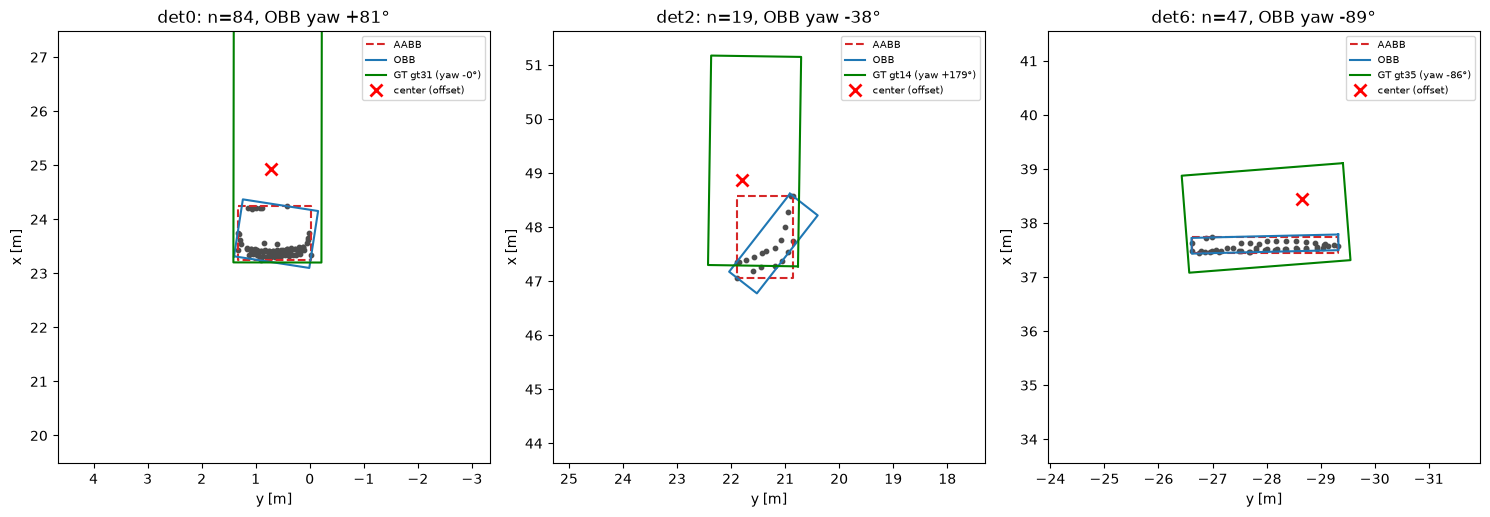

In [18]:
print(f"{'det':>3} {'n':>3} {'AABB size (l,w,h)':>20} {'OBB size':>20} {'OBB yaw°':>8} {'GT yaw°':>7} {'GT size':>20}  판단")
boxes = {}
for k, sel in chosen.items():
    q = pc_velo[sel]
    ca, sa = aabb(q); co, so, yaw = obb_bev(q)
    boxes[k] = (ca, sa, co, so, yaw)
    g, dist = nearest_gt(offset_centers[k])
    gyaw = np.degrees((g.yaw + np.pi / 2) % np.pi - np.pi / 2)            # GT 도 [−90, 90) 으로 감싸 비교
    if dist > 3.0: verdict = "GT 없음 → 비교 불가"
    elif abs(np.degrees(yaw) - gyaw) < 25: verdict = "yaw OK (옆면이 보임)"
    else: verdict = "yaw 실패 (뒷면만 보여 폭 방향이 최대 분산)"
    print(f"{k:>3} {len(sel):>3} ({sa[0]:5.2f},{sa[1]:5.2f},{sa[2]:5.2f})     ({so[0]:5.2f},{so[1]:5.2f},{so[2]:5.2f})     {np.degrees(yaw):+8.1f} {gyaw:+7.1f} ({g.size[0]:5.2f},{g.size[1]:5.2f},{g.size[2]:5.2f})  {verdict}")

# 옆면이 보이는 예: det6 프러스텀의 덩어리 중 GT 중심에 가장 가까운 것(largest 가 배경을 골랐더라도) 의 PCA 방향
sel6, lab6 = frus[6], labels_all[6]
cand = [(min(np.linalg.norm(np.median(pc_velo[sel6[lab6 == c]], axis=0)[:2] - b.center[:2]) for b in gts), c) for c in range(lab6.max() + 1)]
c_side = min(cand)[1]; q6 = pc_velo[sel6[lab6 == c_side]]; g6, d6 = nearest_gt(np.median(q6, axis=0)); _, s6, y6 = obb_bev(q6)
print(f"\ndet6 의 GT 에 가장 가까운 덩어리 c{c_side} (n={len(q6)}, GT gt{g6.tracklet_id} 까지 {d6:.2f} m): OBB yaw {np.degrees(y6):+.1f}° vs GT yaw {np.degrees(g6.yaw):+.1f}° → 옆면이 보이면 PCA 방향이 진행 방향과 맞는다")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, k in zip(axes, [0, 2, 6]):
    q = pc_velo[chosen[k]]; ca, sa, co, so, yaw = boxes[k]
    ax.scatter(q[:, 1], q[:, 0], s=10, c="0.3")
    for (cc, ss, yy, col, ls, name) in [(ca, sa, 0.0, "tab:red", "--", "AABB"), (co, so, yaw, "tab:blue", "-", "OBB")]:
        r = bev_corners(cc, ss, yy); r = np.vstack([r, r[:1]]); ax.plot(r[:, 1], r[:, 0], color=col, ls=ls, lw=1.5, label=name)
    g, dist = nearest_gt(offset_centers[k])
    if dist <= 6.0:
        r = bev_corners(g.center, g.size, g.yaw); r = np.vstack([r, r[:1]]); ax.plot(r[:, 1], r[:, 0], "g-", lw=1.5, label=f"GT gt{g.tracklet_id} (yaw {np.degrees(g.yaw):+.0f}°)")
    ax.plot(offset_centers[k][1], offset_centers[k][0], "rx", ms=9, mew=2, label="center (offset)")
    cy, cx = q[:, 1].mean(), q[:, 0].mean()
    ax.set_xlim(cy + 4, cy - 4); ax.set_ylim(cx - 4, cx + 4); ax.set_aspect("equal"); ax.legend(fontsize=7)
    ax.set_title(f"det{k}: n={len(q)}, OBB yaw {np.degrees(yaw):+.0f}°"); ax.set_xlabel("y [m]"); ax.set_ylabel("x [m]")
plt.tight_layout(); plt.show()

In [19]:
# 검증: 정답지 aabb_from_points / obb_from_points_bev 와 allclose
from perceptrack3d.fusion.point_filters import aabb_from_points, obb_from_points_bev   # 정답지 (검증 전용)
for k, sel in chosen.items():
    q = pc_velo[sel]; ca, sa, co, so, yaw = boxes[k]
    rc, rs = aabb_from_points(q); oc, os_, oy = obb_from_points_bev(q)
    print(f"det{k}: AABB center/size allclose {np.allclose(ca, rc)}/{np.allclose(sa, rs)} | OBB center/size/yaw allclose {np.allclose(co, oc)}/{np.allclose(so, os_)}/{np.isclose(yaw, oy)}")

det0: AABB center/size allclose True/True | OBB center/size/yaw allclose True/True/True
det1: AABB center/size allclose True/True | OBB center/size/yaw allclose True/True/True
det2: AABB center/size allclose True/True | OBB center/size/yaw allclose True/True/True
det3: AABB center/size allclose True/True | OBB center/size/yaw allclose True/True/True
det4: AABB center/size allclose True/True | OBB center/size/yaw allclose True/True/True
det5: AABB center/size allclose True/True | OBB center/size/yaw allclose True/True/True
det6: AABB center/size allclose True/True | OBB center/size/yaw allclose True/True/True


멀리(40 m 밖) 있는 차는 점이 10~30 개라 크기가 실제(4 × 1.8 m) 보다 훨씬 작고, 정면 앞차(det0, GT yaw 0°) 는 뒷면만 보여 **폭 방향**이 최대 분산 → yaw ≈ ±90° 가 나온다. 반대로 옆으로 선 차(det6 의 37 m 덩어리, GT yaw −86°) 는 옆면이 보여 PCA 가 맞는다. 정답지는 그래서 `use_obb: false`(AABB, yaw 0) 를 기본으로 두고, 이 시퀀스에서 **주 산출물은 중심**이라고 못 박았다.

### 이어붙이기 — `fuse_frame_clustered_mine`

조각 1(ROI) → 2(Open3D 지면, 시드 0) → 05 의 투영·축소 박스 → 3(DBSCAN) → 4(largest) → 6(AABB) → 5(오프셋) → 05 의 중복 제거.
정답지와 같은 status 규칙을 붙인다: 필터 뒤 점 0 → `empty`, 5개 미만 → `sparse`, 클러스터 0개 → `invalid/no_cluster`, AABB 의 l 또는 w > `max_extent_m`(15) → `invalid/oversize`, 중복 → `invalid/duplicate_of_k`.

지면 단계만 함수 인자(`non_ground_fn`) 로 빼 둔다. 조각 2 에서 본 것처럼 Open3D 지면은 실행마다 달라서, 검증할 때 "지면 단계만 정답지 것으로 바꾸면 나머지 조립이 정답지와 완전히 같은가" 를 따로 확인하기 위해서다.

In [20]:
def o3d_non_ground(q, g):
    '''조각 2: Open3D segment_plane (시드 0) 으로 지면 inlier 를 찾고, 지면이 *아닌* 점의 (M,) bool mask 를 돌려준다.'''
    o3d.utility.random.seed(0)
    pcd = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(q))
    plane, inl = pcd.segment_plane(distance_threshold=g["distance_threshold"], ransac_n=g["ransac_n"], num_iterations=g["num_iterations"])
    non_ground = np.ones(len(q), bool)
    if abs(plane[2]) >= 0.8:                                               # 법선이 수직에 가까울 때만 지면으로 인정 (벽을 잡으면 제거 안 함)
        non_ground[np.asarray(inl)] = False
    return non_ground

def fuse_frame_clustered_mine(points, dets, calib, image_shape, cfg, non_ground_fn=o3d_non_ground):
    '''조각 1~6 을 이어 붙인 Phase 6. 반환: 검출 순서의 dict 리스트 (status, reason, center, size, yaw, n_points, point_indices).'''
    f = cfg["fusion"]; H, W = image_shape
    c_cfg, half = f["cluster"], f["surface_offset"]["half_depth_m"]
    pc = points[:, :3].astype(np.float64)
    # 1) ROI → 2) 지면 제거 → keep (N,) bool
    roi = roi_mask(pc, f["roi"]); roi_idx = np.flatnonzero(roi)
    keep = np.zeros(len(pc), bool); keep[roi_idx[non_ground_fn(pc[roi_idx], f["ground"])]] = True
    # 3) 투영 (05 조각 1)
    proj = np.hstack((pc, np.ones((len(pc), 1)))) @ calib.P_velo_to_img.T
    depth = proj[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        p2d = proj[:, :2] / depth[:, None]
    in_img = in_box(p2d, (0, 0, W, H)) & (pc[:, 0] > 2.0)
    out = []
    for det in dets:
        sel = np.flatnonzero(in_box(p2d, shrink(det.xyxy, f["box_shrink"])) & in_img & keep)
        o = {"class_name": det.class_name, "confidence": float(det.confidence), "status": "ok", "reason": "",
             "center": None, "size": None, "yaw": None, "n_points": len(sel), "point_indices": sel}
        out.append(o)
        if len(sel) == 0:
            o["status"], o["reason"] = "empty", "no_points_after_filters"; continue
        if len(sel) < f["min_points"]:
            o["status"], o["reason"] = "sparse", f"{len(sel)}<{f['min_points']}_points"; continue
        q = pc[sel]
        lab = np.array(o3d.geometry.PointCloud(o3d.utility.Vector3dVector(q)).cluster_dbscan(eps=c_cfg["eps"], min_points=c_cfg["min_points"]))
        if lab.max() < 0:
            o["status"], o["reason"] = "invalid", "no_cluster"; continue
        member = lab == select_largest(lab, depth[sel])
        qc = q[member]
        _, size = aabb(qc)
        o["n_points"], o["point_indices"] = int(member.sum()), sel[member]
        if size[0] > f["max_extent_m"] or size[1] > f["max_extent_m"]:
            o["status"], o["reason"] = "invalid", f"oversize_{size[0]:.1f}x{size[1]:.1f}m"; continue
        center = np.median(qc, axis=0)
        if f["surface_offset"]["enable"]:
            center = surface_offset(center, qc, half.get(det.class_name, 0.0))
        o["center"], o["size"], o["yaw"] = center, size, 0.0
    # 중복 제거 (05 이어붙이기와 동일)
    kept = []
    for i in sorted([i for i, o in enumerate(out) if o["status"] == "ok"], key=lambda i: -out[i]["confidence"]):
        j = next((j for j in kept if np.linalg.norm(out[i]["center"][:2] - out[j]["center"][:2]) < f["dedup_distance_m"]), None)
        if j is None: kept.append(i)
        else: out[i].update(status="invalid", reason=f"duplicate_of_{j}", center=None, size=None, yaw=None)
    return out

mine = fuse_frame_clustered_mine(pts, dets, calib, (H, W), cfg)
print(f"{'det':>3} {'class':<5} {'status':<8} {'reason':<16} {'n_pts':>5}  center (x, y, z) [m]            size (l, w, h) [m]")
for k, o in enumerate(mine):
    c = "-" if o["center"] is None else "(" + ", ".join(f"{v:6.2f}" for v in o["center"]) + ")"
    s = "-" if o["size"] is None else "(" + ", ".join(f"{v:5.2f}" for v in o["size"]) + ")"
    print(f"{k:>3} {o['class_name']:<5} {o['status']:<8} {o['reason']:<16} {o['n_points']:>5}  {c:<30} {s}")

det class status   reason           n_pts  center (x, y, z) [m]            size (l, w, h) [m]
  0 car   ok                           84  ( 24.92,   0.72,  -0.84)       ( 1.00,  1.36,  0.95)
  1 car   ok                           22  ( 25.72, -14.72,  -1.37)       ( 0.53,  0.39,  0.50)
  2 car   ok                           19  ( 48.87,  21.79,  -0.54)       ( 1.51,  1.04,  0.38)
  3 car   ok                            7  ( 49.86,   4.75,  -1.05)       ( 0.33,  0.45,  0.24)
  4 car   ok                           12  ( 35.72,  22.13,  -0.86)       ( 0.49,  1.42,  0.43)
  5 car   invalid  duplicate_of_3      13  -                              -
  6 car   ok                           47  ( 38.45, -28.66,  -2.44)       ( 0.30,  2.71,  1.16)


In [21]:
# 최종 검증: 정답지 fuse_frame_clustered (기본 = numpy 지면) 와 비교.
#   (a) mine, Open3D 지면          — 조각 2 의 비결정성 때문에 일부 검출이 다를 수 있다
#   (b) mine, 지면만 정답지 remove_ground 주입 — 나머지 조립(프러스텀·DBSCAN·선택·AABB·오프셋·중복 제거) 이 맞으면 전부 일치해야 한다
key_ground = lambda q, g: remove_ground(q, g)[0]                           # 정답지 numpy RANSAC (검증 전용)
mine_kg = fuse_frame_clustered_mine(pts, dets, calib, (H, W), cfg, non_ground_fn=key_ground)

def same(o, ref):
    if o["status"] != ref.status or o["reason"] != ref.reason or o["n_points"] != ref.n_points: return False
    if (o["center"] is None) != (ref.center is None): return False
    if o["center"] is None: return True
    return np.allclose(o["center"], ref.center) and np.allclose(o["size"], ref.size)

fx = lambda c: f"{c[0]:6.2f}" if c is not None else "   -  "
print(f"{'det':>3} {'(a) mine o3d 지면':>17} {'(b) mine 정답지 지면':>19} {'정답지 (numpy)':>15} {'(a)=정답지':>9} {'(b)=정답지':>9}")
for k, (o, o2, b) in enumerate(zip(mine, mine_kg, ref_np)):
    print(f"{k:>3} {o['status']:<8}{fx(o['center']):>8}  {o2['status']:<8}{fx(o2['center']):>8}  {b.status:<8}{fx(b.center):>8} {str(same(o, b)):>9} {str(same(o2, b)):>9}")

# 전체 시퀀스에서 같은 비교
n_det = 0; bad_a = []; bad_b = []
for fid in ds.frame_ids():
    if not dets_all.get(fid): continue
    f2 = ds.load_frame(fid); shp = f2["image"].shape[:2]
    a = fuse_frame_clustered_mine(f2["points"], dets_all[fid], calib, shp, cfg)
    a2 = fuse_frame_clustered_mine(f2["points"], dets_all[fid], calib, shp, cfg, non_ground_fn=key_ground)
    b = fuse_frame_clustered(f2["points"], dets_all[fid], calib, shp, cfg)
    for k, (x, x2, y) in enumerate(zip(a, a2, b)):
        n_det += 1
        if not same(x, y):
            big = x["status"] != y.status or (x["center"] is not None and np.linalg.norm(x["center"][:2] - y.center[:2]) > 0.5)   # status 가 다르거나 중심이 0.5 m 넘게 다름
            bad_a.append((fid, k, big))
        if not same(x2, y): bad_b.append((fid, k))
n_big = sum(b for _, _, b in bad_a)
print(f"\n전체 시퀀스 검출 {n_det} 건 중 정답지와 다른 것:")
print(f"  (a) Open3D 지면      {len(bad_a)} 건 — 그중 status 가 다르거나 중심이 0.5 m 넘게 다른 것 {n_big} 건 (나머지는 지면 경계 점 몇 개 차이), 예 {[(f, k) for f, k, b in bad_a if b][:6]}")
print(f"  (b) 정답지 지면 주입  {len(bad_b)} 건 {bad_b[:6]}")

det   (a) mine o3d 지면     (b) mine 정답지 지면     정답지 (numpy)   (a)=정답지   (b)=정답지
  0 ok         24.92  ok         24.92  ok         24.92      True      True
  1 ok         25.72  ok         37.93  ok         37.93     False      True
  2 ok         48.87  ok         48.68  ok         48.68     False      True
  3 ok         49.86  ok         49.86  ok         49.86      True      True
  4 ok         35.72  ok         35.72  ok         35.72      True      True
  5 invalid      -    invalid      -    invalid      -        True      True
  6 ok         38.45  ok         38.45  ok         38.45     False      True



전체 시퀀스 검출 1325 건 중 정답지와 다른 것:
  (a) Open3D 지면      367 건 — 그중 status 가 다르거나 중심이 0.5 m 넘게 다른 것 37 건 (나머지는 지면 경계 점 몇 개 차이), 예 [(7, 4), (15, 3), (25, 1), (55, 1), (55, 6), (71, 1)]
  (b) 정답지 지면 주입  0 건 []


(b) 가 0 건이면 지면 단계 이후의 조립은 정답지와 같다는 뜻이고, (a) 의 차이는 전부 조각 2 의 Open3D 비결정성에서 온다. 어느 검출이 달라지는지는 실행마다 바뀌지만, 대부분 먼 물체(지면 평면의 기울기 차이가 커지는 곳) 다.

### 프레임 0 / 50 / 150 — raw vs clustered 의 GT 대비 BEV 오차 (정답지 `comparison.md` 대표 프레임 표 재현)

정답지 평가 코드(`scripts/compare_fusion.py::evaluate_objects`, 2 m 헝가리안 매칭) 에 A: 정답지 raw (05 기준선), B(mine, Open3D 지면), B(mine, 정답지 지면 주입), B(정답지) 를 넣는다.
`comparison.md` 의 값 — frame 0: raw 1.45 / clustered 0.57, frame 50: 1.73 / 0.69, frame 150: nan(매칭 0) / 0.65 (BEV mean, m).

In [22]:
import sys
sys.path.insert(0, f"{cfg['outputs']['dir']}/../scripts")
from compare_fusion import evaluate_objects                                # 정답지 (검증 전용)
from perceptrack3d.fusion.frustum_fusion import fuse_frame_raw             # 정답지 Phase 5 (검증 전용)
from perceptrack3d.types import Object3D

def to_obj(o, det):                                                        # dict → Object3D (evaluate_objects 입력 형식)
    return Object3D(frame_id=det.frame_id, class_name=o["class_name"], confidence=o["confidence"], xyxy=np.asarray(det.xyxy),
                    center=o["center"], size=o["size"], yaw=o["yaw"], n_points=o["n_points"], status=o["status"], method="clustered", reason=o["reason"])

print(f"{'frame':>5} {'변형':<14} {'GT':>3} {'ok':>3} {'매칭':>4} {'재현율':>6} {'정밀도':>6} {'BEV mean':>8} {'BEV median':>10} {'깊이 bias':>9}")
for fid in [0, 50, 150]:
    f2 = ds.load_frame(fid); shp = f2["image"].shape[:2]
    variants = [("A raw (정답지)", fuse_frame_raw(f2["points"], dets_all[fid], calib, shp, cfg)),
                ("B mine, o3d 지면", [to_obj(o, d) for o, d in zip(fuse_frame_clustered_mine(f2["points"], dets_all[fid], calib, shp, cfg), dets_all[fid])]),
                ("B mine, 정답지 지면", [to_obj(o, d) for o, d in zip(fuse_frame_clustered_mine(f2["points"], dets_all[fid], calib, shp, cfg, non_ground_fn=key_ground), dets_all[fid])]),
                ("B 정답지", fuse_frame_clustered(f2["points"], dets_all[fid], calib, shp, cfg))]
    for name, objs in variants:
        r = evaluate_objects({fid: objs}, gts_all, cfg, 2.0)
        print(f"{fid:>5} {name:<16} {r['n_gt']:>3} {r['n_pred_ok']:>3} {r['n_matched']:>4} {r['recall']:>6.2f} {r['precision']:>6.2f} {r['center']['mean_bev']:>8.2f} {r['center']['median_bev']:>10.2f} {r['depth']['bias']:>+9.2f}")

frame 변형              GT  ok   매칭    재현율    정밀도 BEV mean BEV median   깊이 bias
    0 A raw (정답지)        3   3    2   0.67   0.67     1.45       1.45     -1.45
    0 B mine, o3d 지면     3   3    3   1.00   1.00     0.57       0.63     -0.01
    0 B mine, 정답지 지면     3   3    3   1.00   1.00     0.57       0.63     -0.01
    0 B 정답지              3   3    3   1.00   1.00     0.57       0.63     -0.01
   50 A raw (정답지)        4   3    1   0.25   0.33     1.73       1.73     -1.71
   50 B mine, o3d 지면     4   3    2   0.50   0.67     0.69       0.69     -0.29
   50 B mine, 정답지 지면     4   3    2   0.50   0.67     0.69       0.69     -0.29
   50 B 정답지              4   3    2   0.50   0.67     0.69       0.69     -0.29
  150 A raw (정답지)        5   1    0   0.00   0.00      nan        nan      +nan
  150 B mine, o3d 지면     5   1    1   0.20   1.00     0.65       0.65     -0.62
  150 B mine, 정답지 지면     5   1    1   0.20   1.00     0.65       0.65     -0.62
  150 B 정답지              5   1    1   0.20

### 여기서 배우는 것

- **비결정적인 라이브러리 호출은 재현성을 깨뜨린다**: Open3D `segment_plane` 은 시드 없이는 매번 다르고, 시드를 걸어도 같은 프로세스 안에서조차 달라질 수 있다. 검증·회귀 테스트가 필요하면 numpy 로 다시 쓰는 편이 낫다 (정답지 `ransac_plane`). 비결정적 단계는 함수 인자로 빼 두면 나머지를 따로 검증할 수 있다 (`non_ground_fn`).
- **앞 단계의 작은 차이가 뒤 단계를 뒤집는다**: 지면 평면의 법선이 0.005 rad 만 달라도 40 m 밖에서는 0.2 m — `distance_threshold` 와 같은 크기다. 먼 차의 하부 점이 지면으로 깎이면 클러스터가 쪼개져 largest 규칙이 배경을 고른다 (det6). 문서와 출력이 어긋나면 출력을 믿고 원인을 찾는다.
- **같은 알고리즘, 다른 구현은 같아야 한다**: DBSCAN 은 Open3D 와 scikit-learn 이 라벨 번호까지 같았다. `min_points`/`min_samples` 가 "자기 자신 포함" 인지 문서에서 확인한다.
- **가장 큰 개선은 통계가 아니라 외부 정보였다**: 표면→중심 오프셋(클래스 크기 prior) 이 BEV 오차 1.39 → 0.63 m 를 만들었다. 클러스터링만으로는 raw 와 오차가 같다. 대신 prior 가 틀리면(Van→car) 그만큼 틀린다.
- **PCA 방향 ≠ 진행 방향**: LiDAR 는 보이는 면만 찍어 L 자·I 자 모양이라, 정면 차는 폭 방향이 최대 분산이다. `eigh` 의 고유값이 오름차순이라 마지막 열이 최대 분산 방향인 것도 문서로 확인해야 한다.

### 자가 점검 3문제

1. `segment_plane` 이 돌려주는 `[a, b, c, d]` 에서 "원점 아래 지면 높이" 는 어떻게 구하나? 이 노트북의 두 평면(Open3D vs numpy) 이 원점에서는 몇 mm 차이인데 40 m 밖에서 0.2 m 가 되는 이유는?
2. det4 의 프러스텀에는 (5점, 25.9 m), (6점, 37.3 m), (12점, 34.2 m) 세 덩어리가 있고 GT 는 36.3 m 에 있다. `nearest` 와 `largest` 는 각각 무엇을 고르며, `cluster_min_ratio=0.3` 은 어느 쪽을 어떻게 바꾸나?
3. 표면 오프셋의 `push = max(0, half − extent/2)` 에서 `extent/2` 를 빼는 이유는? 옆면까지 다 보이는 가까운 차(extent ≈ 4 m) 에는 얼마를 미나?

<details><summary>답</summary>

1. x = y = 0 을 평면식에 넣어 z = −d / c (c > 0 으로 정규화했을 때). 두 평면은 원점에서 약 5 mm 차이지만 법선 (a, b) 가 0.005 rad 정도 달라서, 높이 차이 ≈ (Δa·x + Δb·y) 가 거리에 비례해 커진다. 40 m 에서 0.005 × 40 = 0.2 m.
2. nearest → 25.9 m 의 5점 덩어리(지면 잔여·풀; 틀림), largest → 34.2 m 의 12점 덩어리(GT 36.3 m 와 표면 편차만큼 차이; 맞음). `cluster_min_ratio=0.3` 은 최대 클러스터(12점) 의 30% = 3.6점 이상만 후보로 두므로 5점 덩어리도 후보에 남아 여전히 25.9 m 를 고른다. ratio 를 0.5 로 올리면(6점 이상) 5점 덩어리가 빠져 34.2 m 로 간다 — 어느 값이 맞는지는 장면 통계에 달렸다.
3. 클러스터 점이 시선 방향으로 이미 `extent` 만큼 퍼져 있으면 그 절반은 이미 "보이는 깊이" 라서, 표면 중앙값은 이미 물체 안쪽 extent/2 에 있다. 남은 만큼(half − extent/2) 만 밀어야 이중 보정이 안 된다. extent ≈ 4 m 인 car(half 2.0) 는 push = max(0, 2 − 2) = 0, 즉 밀지 않는다.
</details>